# =============================== # Modelling Notebook # ===============================

## Objectives

- Fit and evaluate regression models to predict SalePrice.
- Apply feature engineering pipeline developed earlier.
- Compare candidate regression models using cross-validation.
- Select best model and optimise hyperparameters.
- Export final train/test sets, pipelines, and feature importance plot.


## Inputs 
- outputs/datasets/processed/TrainSet.csv
- outputs/datasets/processed/TestSet.csv

## Outputs
- Train set (features and target)
- Test set (features and target)
- Data cleaning and Feature Engineering pipeline
- Modeling pipeline
- Feature importance plot

### Import Cell

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split

# Pipelines
from sklearn.pipeline import Pipeline

# Feature Engineering
from feature_engine.selection import SmartCorrelatedSelection
from feature_engine.outliers import Winsorizer
from sklearn.preprocessing import PowerTransformer

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Feature Selection
from sklearn.feature_selection import SelectFromModel

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor

# Hyperparameter Search
from sklearn.model_selection import GridSearchCV

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

---

## Change working directory

We need to set the current working directory to the parent folder for consistency.

In [139]:
# Check current directory
current_dir = os.getcwd()
print("Current directory:", current_dir)

# Move to parent directory
os.chdir(os.path.dirname(current_dir))
print("New current directory:", os.getcwd())

Current directory: c:\
New current directory: c:\


Confirm the new current directory

In [140]:
current_dir = os.getcwd()
current_dir

'c:\\'

## Load Cleaned Data

We load the cleaned dataset and split it into Train and Test sets.



In [ ]:
BASE_DIR = Path(r"C:\Users\david\Portfolio 5\heritage-housing")
data_path = BASE_DIR / "outputs/datasets/cleaned/CleanedData.csv"

# Load data
df = pd.read_csv(data_path)

# Split into Train and Test sets
TrainSet, TestSet = train_test_split(df, test_size=0.2, random_state=42)

print("TrainSet shape:", TrainSet.shape)
print("TestSet shape:", TestSet.shape)

TrainSet shape: (1168, 22)
TestSet shape: (292, 22)


---

## Helper Functions

These functions help check missing values and generate diagnostic plots for numeric and categorical features.

In [ ]:
def evaluate_regression (x, y, pipeline):
    """
    Evaluates a trained regression model using common performance metrics.
    """
    y_pred = pipeline.predict(X)

    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)

    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)

    return mae, rmse, r2

def plot_predictions(x, y, pipeline):
    """
    Plots actual vs predicted values for regression model evaluation.
    """
    y_pred = pipeline.predict(X)

    plt.figure(figsize=(6,6))
    plt.scatter(y, y_pred)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Actual vs Predicted")
    plt.show())

def plot_residuals(x, y, pipeline):
    """
    Plots residuals (errors) of a regression model to assess model fit.
    Residuals are calculated as: actual - predicted.
    """
    y_pred = pipeline.predict(X)
    residuals = y - y_pred

    plt.figure(figsize=(6,4))
    sns.histplot(residuals, kde= true)
    plt.xlabel("Residuals (Actual - Predicted)")
    plt.title("Residual Distribution")
    plt.show()

import os
import joblib

def save_model_outputs(model, file_path):
    """
    Saves a trained machine learning pipeline to a specified directory.
    """

    os.makedirs(file_path, exist_ok=True)

    joblib.dump(model, f"{file_path}/model.pkl")

    print(f"Model successfully saved to: {file_path}")

# ===============================
## Feature Engineering Pipeline
# ===============================

### Phase 1: Transformation Exploration & Selection

In [ ]:
def PipelineDataCleaningAndFeatureEngineering():
    """
    Light feature engineering pipeline for regression.
    """

    pipeline = Pipeline([
        ("correlation_selection",
         SmartCorrelatedSelection(
             variables=None,
             method="spearman",
             threshold=0.6,
             selection_method="variance"
         )
        ),

        ("outliers",
         Winsorizer(
             capping_method="iqr",
             tail="both",
             fold=1.5,
             variables=['GrLivArea', 'LotArea', 'TotalBsmtSF']
         )
        )
    ])

    return pipeline

* No missing values found.


In [ ]:
pipeline_fe = PipelineDataCleaningAndFeatureEngineering()

X_train = pipeline_fe.fit_transform(X_train)
X_test = pipeline_fe.transform(X_test)

### Model Benchmarking

#### Define Candidate Models

In [ ]:
models_quick_search = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42),
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42)
}

,Feature,Original Skew,Log1p Skew
0,GrLivArea,1.425139,0.007943
1,LotArea,11.958088,-0.012599
2,TotalBsmtSF,1.723881,-5.274632
3,1stFlrSF,1.422162,0.026976
4,BsmtFinSF1,1.862132,-0.622601


### Define Hyperparameter Grids (Baseline)

In [ ]:
params_quick_search = {
    "LinearRegression": {},
    "Ridge": {},
    "Lasso": {},
    "RandomForestRegressor": {},
    "GradientBoostingRegressor": {},
    "ExtraTreesRegressor": {},
    "XGBRegressor": {}
}

### Run GridSearchCV (Quick Benchmark)

In [ ]:
search = HyperparameterOptimizationSearch(
    models=models_quick_search,
    params=params_quick_search
)

search.fit(
    X_train,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)

### Evaluate Model Performance

In [ ]:
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')

grid_search_summary

### Ordinal Categorical Variables

- `KitchenQual`, `ExterQual`, `ExterCond`, `BsmtQual`, `BsmtCond`, `GarageQual`, `GarageCond`, `FireplaceQu`  
These features have a natural order, so we will encode them numerically.

### Numeric Variables for Transformation:
- `GrLivArea`, `LotArea`, `TotalBsmtSF`, `1stFlrSF`, `BsmtFinSF1`  
These features are right-skewed or have outliers and could potentially benefit from log/power/Box-Cox transformations.

### Variables for Correlation-Based Reduction:
- All numeric features  
To reduce multicollinearity and  thus keep only the most informative features.

---

In [ ]:
# Box-Cox selected for strongly positive, right-skewed features
boxcox_vars = ['GrLivArea', '1stFlrSF']

# Yeo-Johnson selected for skewed features that may contain zero/negative values
yeojohnson_vars = ['LotArea', 'TotalBsmtSF', 'BsmtFinSF1']


# Apply Box-Cox
pt_boxcox = PowerTransformer(method="box-cox")
TrainSet[boxcox_vars] = pt_boxcox.fit_transform(TrainSet[boxcox_vars])
TestSet[boxcox_vars] = pt_boxcox.transform(TestSet[boxcox_vars])

# Apply Yeo-Johnson
pt_yeo = PowerTransformer(method="yeo-johnson")
TrainSet[yeojohnson_vars] = pt_yeo.fit_transform(TrainSet[yeojohnson_vars])
TestSet[yeojohnson_vars] = pt_yeo.transform(TestSet[yeojohnson_vars])

print("* Numerical transformations applied (Box-Cox + Yeo-Johnson)")

* Numerical transformations applied (Box-Cox + Yeo-Johnson)


### Smart Correlation 

- Spearman correlation is used as the method because the dataset contains skewed numerical variables with outliers, and we are interested in monotonic relationships rather than strictly linear dependencies.
- Correlation analysis is used to identify redundant features and reduce multicollinearity before modeling.

In [ ]:
from feature_engine.selection import SmartCorrelatedSelection
corr_sel = SmartCorrelatedSelection(
    variables=None,
    method="spearman",
    threshold=0.6,
    selection_method="variance"
)

corr_sel.fit_transform(TrainSet)

print("Correlated feature sets:")
print(corr_sel.correlated_feature_sets_)

print("Features to drop:")
print(corr_sel.features_to_drop_)

Correlated feature sets:
[{'GrLivArea', 'GarageArea', 'OverallQual', 'YearBuilt', 'SalePrice'}, {'YearRemodAdd', 'GarageYrBlt'}, {'1stFlrSF', 'TotalBsmtSF'}]
Features to drop:
['GarageArea', 'YearBuilt', 'OverallQual', 'GrLivArea', 'YearRemodAdd', 'TotalBsmtSF']


# ===============================
## Phase 2: Final Pipeline (Model Ready)
# ===============================

## Apply Feature Engineering Transformers

### Ordinal Categorical Encoding 
We encode ordinal categorical variables to numeric values.

In [ ]:
ordinal_vars = ['KitchenQual', 'BsmtExposure', 'BsmtFinType1', 'GarageFinish']

encoder = OrdinalEncoder(
    encoding_method="arbitrary",
    variables=ordinal_vars,
    missing_values="ignore"
)

TrainSet = encoder.fit_transform(TrainSet)
TestSet = encoder.transform(TestSet)

c:\Users\david\Portfolio 5\heritage-housing\venv\Lib\site-packages\feature_engine\encoding\base_encoder.py:260: UserWarning: During the encoding, NaN values were introduced in the feature(s) BsmtExposure, BsmtFinType1, GarageFinish.
  warnings.warn(
c:\Users\david\Portfolio 5\heritage-housing\venv\Lib\site-packages\feature_engine\encoding\base_encoder.py:260: UserWarning: During the encoding, NaN values were introduced in the feature(s) BsmtExposure, BsmtFinType1, GarageFinish.
  warnings.warn(


### Outlier Handling (Winsorization)
Apply IQR-based Winsorization to selected numeric features.

---

In [ ]:
from feature_engine.outliers import Winsorizer

# Select numeric variables for Winsorization (only skewed ones)
winsor_vars = ['GrLivArea', 'LotArea', 'TotalBsmtSF']

# Fit on TrainSet, transform TestSet
winsor = Winsorizer(
    capping_method='iqr',
    tail='both',
    fold=1.5,
    variables=winsor_vars
)

TrainSet = winsor.fit_transform(TrainSet)
TestSet = winsor.transform(TestSet)

print("* Winsorization applied!")

* Winsorization applied!


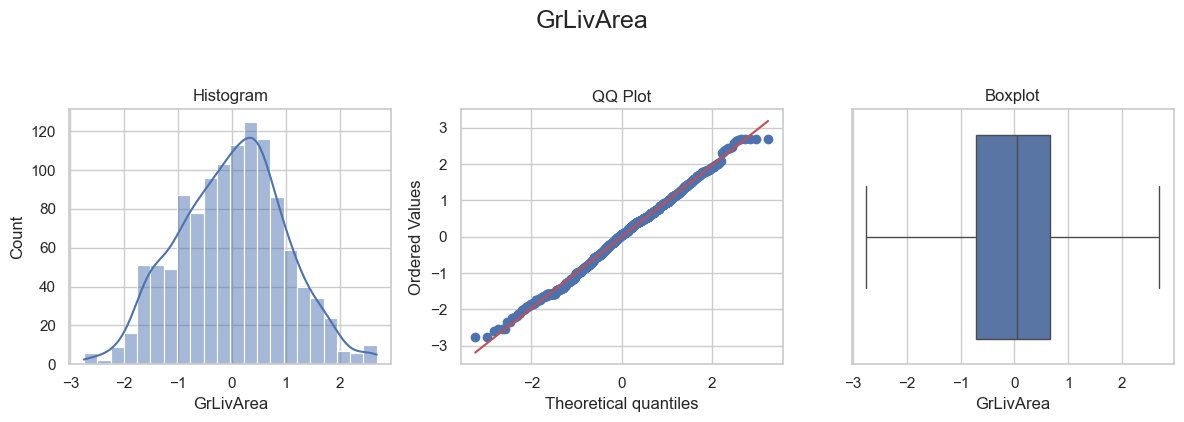

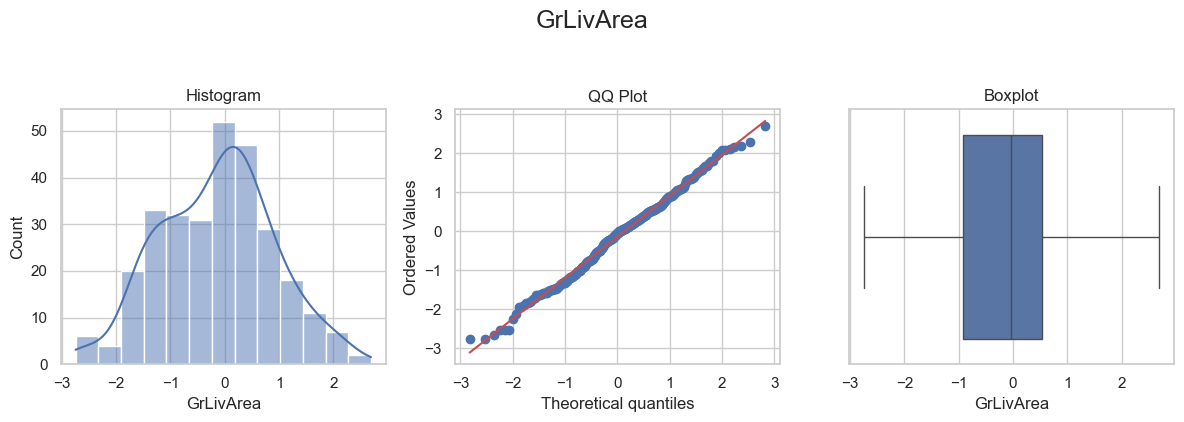

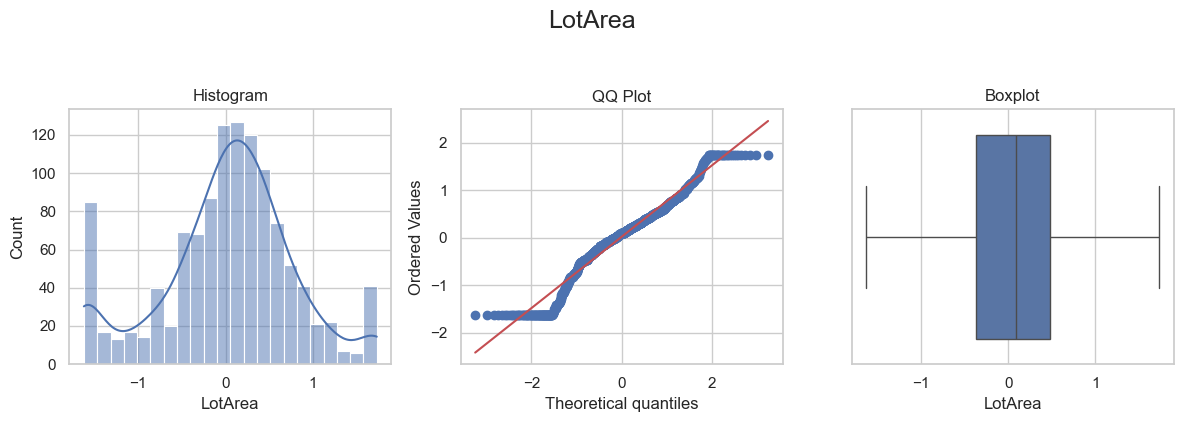

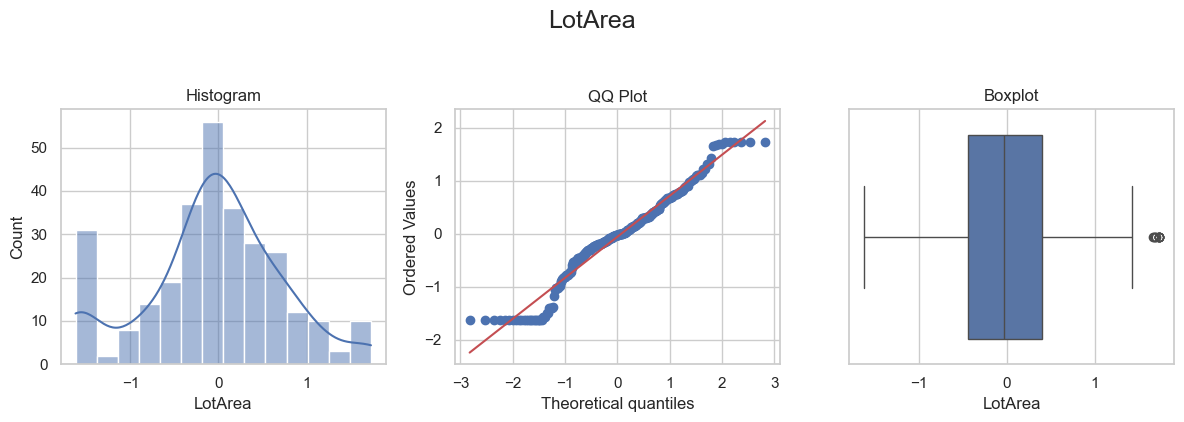

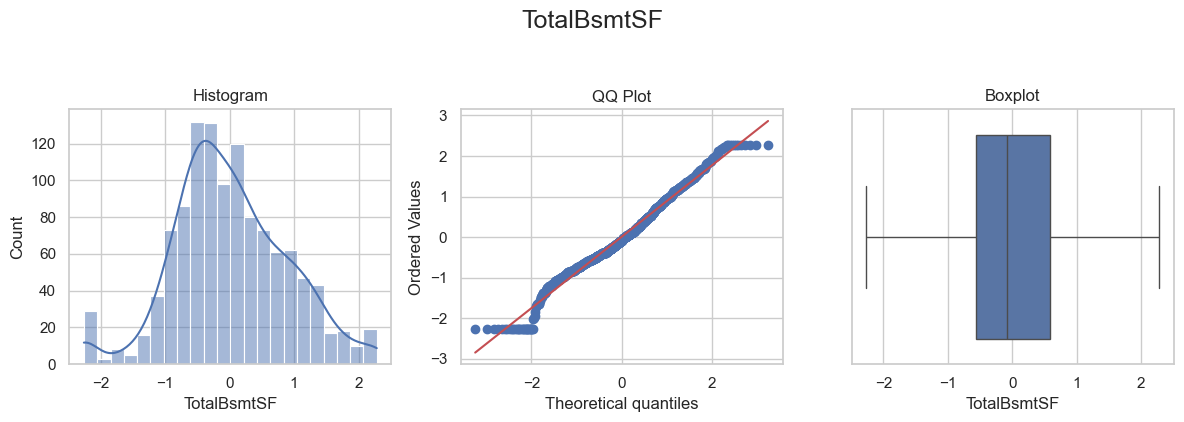

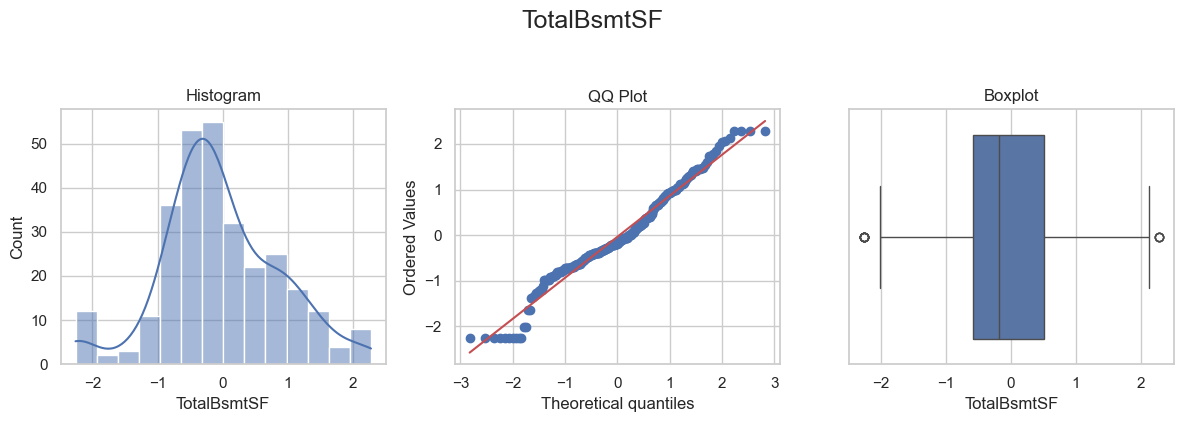

In [ ]:
# Evaluate Winsorization visually (Train vs Test consistency check)
for col in winsor_vars:
    diagnostic_plots(TrainSet, col)
    diagnostic_plots(TestSet, col)

### Numerical Transformations 
- Apply Power Transformations to reduce skewness
- Box-Cox applied to strictly positive features
- Yeo-Johnson applied to all remaining skewed features 

### Transformation Summary
Final selected transformations are implemented in Phase 2 pipeline.

In [ ]:
print("=== FINAL FEATURE ENGINEERING SUMMARY ===")

print("\nOrdinal encoded variables:")
print(ordinal_vars)

print("\nBox-Cox variables:")
print(boxcox_vars)

print("\nYeo-Johnson variables:")
print(yeojohnson_vars)

print("\nWinsorized variables:")
print(winsor_vars)

print("\nCorrelation-based dropped features:")
print(corr_sel.features_to_drop_)

=== FINAL FEATURE ENGINEERING SUMMARY ===

Ordinal encoded variables:
['KitchenQual', 'BsmtExposure', 'BsmtFinType1', 'GarageFinish']

Box-Cox variables:
['GrLivArea', '1stFlrSF']

Yeo-Johnson variables:
['LotArea', 'TotalBsmtSF', 'BsmtFinSF1']

Winsorized variables:
['GrLivArea', 'LotArea', 'TotalBsmtSF']

Correlation-based dropped features:
['GarageArea', 'YearBuilt', 'OverallQual', 'GrLivArea', 'YearRemodAdd', 'TotalBsmtSF']
